# Đánh giá khách quan trên tập Test (Evaluation)

Mục tiêu:
- Nạp 10000 ảnh từ tập Test
- Nạp lại bộ trọng số tốt nhất (Epoch 13)
- Chạy dự đoán 1 lần trên tập Test
- Dựng Confusion Matrix & Classification Report để đối chiếu với mô hình CNN tự xây cũ.

In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Sử dụng thiết bị CUDA: {device}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Sử dụng thiết bị Apple Metal Performance Shaders: {device}")
else:
    device = torch.device("cpu")
    print(f"Sử dụng CPU: {device}")

Sử dụng thiết bị Apple Metal Performance Shaders: mps


## Nạp test dataset
Tập Test phải được áp dụng bộ `eval_transform` (giữ nguyên bản, không làm méo hay xoay ảnh) và chuẩn hóa đúng hằng số của ImageNet.

In [2]:
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=eval_transform)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Đã mở két sắt: Sẵn sàng {len(test_dataset)} ảnh Test.")

Đã mở két sắt: Sẵn sàng 10000 ảnh Test.


## Gọi mô hình VGG16 tốt nhất
Khởi tạo lại khung mạng và nạp bộ trọng số đã được lưu từ step 4.

In [3]:
model = models.vgg16()
model.classifier[6] = nn.Linear(model.classifier[6].in_features, 10)

model_path = "models/vgg16_best_transfer_learning.pth"
model.load_state_dict(torch.load(model_path, weights_only=True))

model = model.to(device)
model.eval()

print("Đã nạp thành công bộ trọng số tốt nhất. Bắt đầu test...")

Đã nạp thành công bộ trọng số tốt nhất. Bắt đầu test...


## Thu thập kết quả và làm báo cáo
Cho mô hình dự đoán toàn bộ tập Test. Sau đó so sánh đáp án của AI (`y_pred`) với đáp án thật (`y_true`) để vẽ biểu đồ nhiệt và bảng thống kê học thuật.

Hoàn thành dự đoán 10.000 ảnh!

------------------------------------------------------------
BẢNG BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
------------------------------------------------------------
              precision    recall  f1-score   support

 T-shirt/top     0.8545    0.8630    0.8587      1000
     Trouser     0.9949    0.9780    0.9864      1000
    Pullover     0.8925    0.8550    0.8733      1000
       Dress     0.8527    0.9380    0.8933      1000
        Coat     0.8839    0.8680    0.8759      1000
      Sandal     0.9800    0.9810    0.9805      1000
       Shirt     0.7323    0.7140    0.7230      1000
     Sneaker     0.9421    0.9760    0.9587      1000
         Bag     0.9879    0.9790    0.9834      1000
  Ankle boot     0.9813    0.9460    0.9633      1000

    accuracy                         0.9098     10000
   macro avg     0.9102    0.9098    0.9097     10000
weighted avg     0.9102    0.9098    0.9097     10000



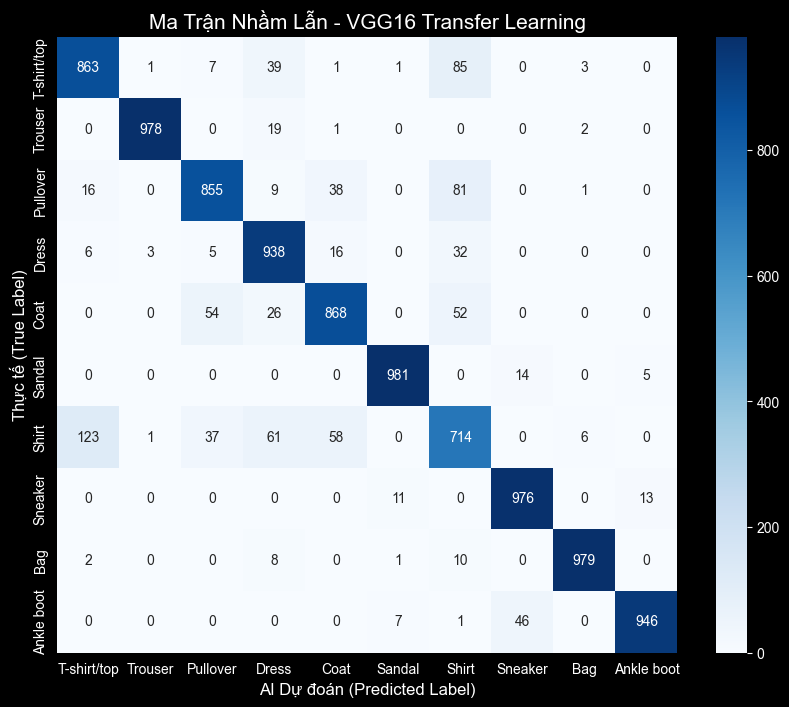

In [4]:
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        # Lấy class có xác suất cao nhất làm dự đoán
        _, preds = torch.max(outputs, 1)

        # Đưa kết quả về lại CPU và chuyển thành list để đưa vào thư viện sklearn
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("Hoàn thành dự đoán 10.000 ảnh!\n")
print("-" * 60)
print("BẢNG BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("-" * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('AI Dự đoán (Predicted Label)', fontsize=12)
plt.ylabel('Thực tế (True Label)', fontsize=12)
plt.title('Ma Trận Nhầm Lẫn - VGG16 Transfer Learning', fontsize=15)
plt.show()